# Rapport de performance — Optimisation du modèle de scoring

En production, l'API redémarre régulièrement (déploiement, restart Docker). Le chargement du modèle via `mlflow.pyfunc` me semblait lent — j'ai voulu mesurer si passer directement par `joblib` changeait quelque chose.

| | Baseline | Optimisé |
|---|---|---|
| Chargement | `mlflow.pyfunc.load_model` | `joblib.load` |
| Inférence | `model.predict` | `model.predict_proba` |

Benchmark : 200 itérations sur des données réelles (`data/train_sample.csv`), mesures de chargement, préprocess, inférence et CPU. La piste ONNX Runtime a également été explorée — les résultats sont en section 5.

In [10]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def print_results(data):
    print(f"Loader : {data['loader']}")
    print(f"Chargement du modèle : {data['load_time_ms']:.1f} ms\n")
    for section in ["preprocess", "inference", "cpu"]:
        unit = "%" if section == "cpu" else "ms"
        d = data[section]
        print(f"{section.capitalize()} ({unit})")
        print(f"  mean   : {d['mean']:.3f}")
        print(f"  median : {d['median']:.3f}")
        print(f"  p95    : {d['p95']:.3f}")
        print(f"  p99    : {d['p99']:.3f}")
        print()

with open("benchmark_mlflow_pyfunc.json") as f:
    mlflow_data = json.load(f)

with open("benchmark_joblib.json") as f:
    joblib_data = json.load(f)

print(f"mlflow.pyfunc — run_at : {mlflow_data['run_at']}  |  n_iter : {mlflow_data['n_iter']}")
print(f"joblib        — run_at : {joblib_data['run_at']}  |  n_iter : {joblib_data['n_iter']}")

mlflow.pyfunc — run_at : 2026-04-28T16:15:55.811632  |  n_iter : 200
joblib        — run_at : 2026-04-28T16:16:02.847517  |  n_iter : 200


## 1. Résultats — version baseline (mlflow.pyfunc)

In [11]:
print_results(mlflow_data)

Loader : mlflow.pyfunc
Chargement du modèle : 2868.7 ms

Preprocess (ms)
  mean   : 3.121
  median : 3.028
  p95    : 3.716
  p99    : 4.470

Inference (ms)
  mean   : 5.730
  median : 5.360
  p95    : 7.980
  p99    : 11.692

Cpu (%)
  mean   : 14.565
  median : 14.300
  p95    : 50.000
  p99    : 54.500



## 2. Résultats — version optimisée (joblib)

In [12]:
print_results(joblib_data)

Loader : joblib
Chargement du modèle : 874.1 ms

Preprocess (ms)
  mean   : 3.315
  median : 3.233
  p95    : 4.142
  p99    : 4.496

Inference (ms)
  mean   : 5.967
  median : 5.569
  p95    : 8.563
  p99    : 10.117

Cpu (%)
  mean   : 15.623
  median : 14.300
  p95    : 50.000
  p99    : 53.807



## 3. Comparaison avant / après

In [13]:
def gain_pct(before, after):
    return (after - before) / before * 100

print("=" * 65)
print(f"{'Métrique':<30} {'mlflow':>8} {'joblib':>8} {'delta':>8}  sens")
print("=" * 65)

load_gain = gain_pct(mlflow_data["load_time_ms"], joblib_data["load_time_ms"])
sens = "✓ amélioration" if load_gain < 0 else "✗ régression"
print(f"{'Chargement (ms)':<30} {mlflow_data['load_time_ms']:>8.1f} {joblib_data['load_time_ms']:>8.1f} {load_gain:>+7.1f}%  {sens}")

for section in ["preprocess", "inference"]:
    for stat in ["mean", "p95"]:
        before = mlflow_data[section][stat]
        after  = joblib_data[section][stat]
        g = gain_pct(before, after)
        sens = "✓ amélioration" if g < 0 else "✗ régression"
        label = f"{section.capitalize()} {stat} (ms)"
        print(f"{label:<30} {before:>8.3f} {after:>8.3f} {g:>+7.1f}%  {sens}")

print("=" * 65)
print(f"\nScore de référence — mlflow : {mlflow_data['ref_score']} | joblib : {joblib_data['ref_score']}")
print("→ Prédictions identiques ✓" if mlflow_data["ref_score"] == joblib_data["ref_score"] else "→ Prédictions différentes ✗")

Métrique                         mlflow   joblib    delta  sens
Chargement (ms)                  2868.7    874.1   -69.5%  ✓ amélioration
Preprocess mean (ms)              3.121    3.315    +6.2%  ✗ régression
Preprocess p95 (ms)               3.716    4.142   +11.5%  ✗ régression
Inference mean (ms)               5.730    5.967    +4.1%  ✗ régression
Inference p95 (ms)                7.980    8.563    +7.3%  ✗ régression

Score de référence — mlflow : 0.8173 | joblib : 0.8173
→ Prédictions identiques ✓


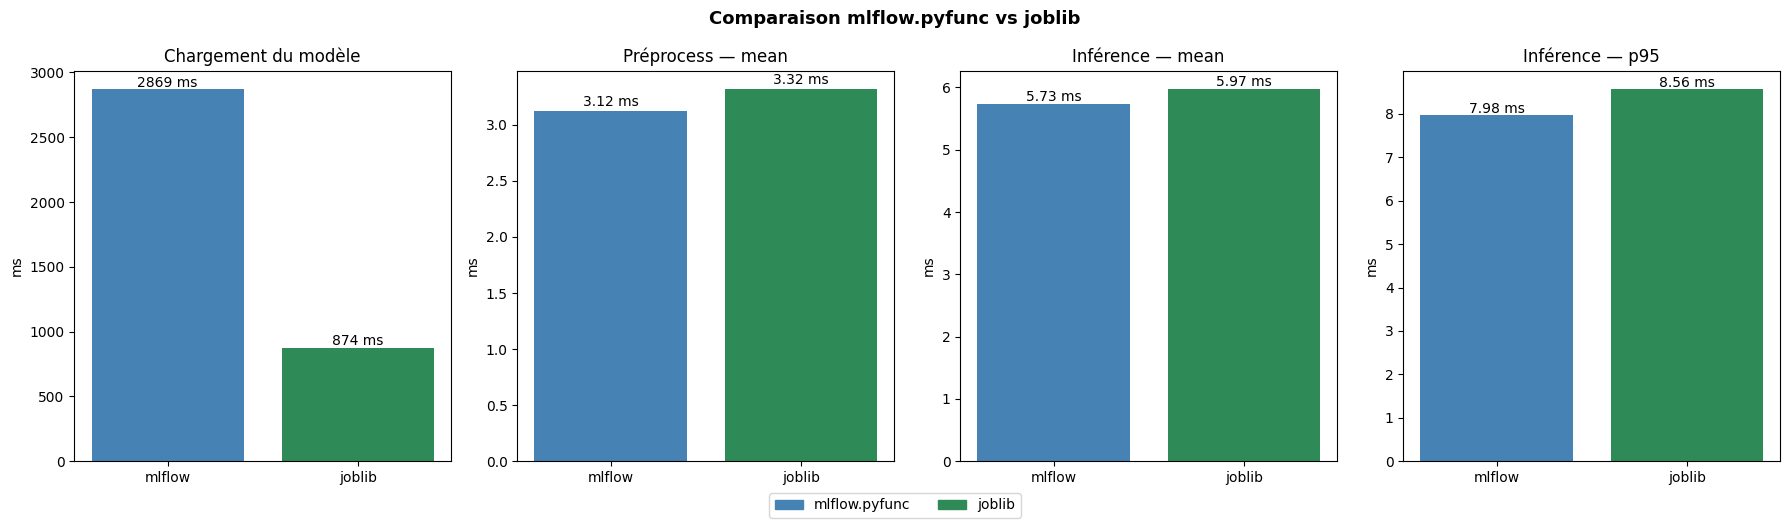

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Comparaison mlflow.pyfunc vs joblib", fontsize=13, fontweight="bold")

blue  = "steelblue"
green = "seagreen"

ax = axes[0]
vals = [mlflow_data["load_time_ms"], joblib_data["load_time_ms"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Chargement du modèle")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 20, f"{v:.0f} ms", ha="center", fontsize=10)

ax = axes[1]
vals = [mlflow_data["preprocess"]["mean"], joblib_data["preprocess"]["mean"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Préprocess — mean")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.2f} ms", ha="center", fontsize=10)

ax = axes[2]
vals = [mlflow_data["inference"]["mean"], joblib_data["inference"]["mean"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Inférence — mean")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.2f} ms", ha="center", fontsize=10)

ax = axes[3]
vals = [mlflow_data["inference"]["p95"], joblib_data["inference"]["p95"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Inférence — p95")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.2f} ms", ha="center", fontsize=10)

legend = [
    mpatches.Patch(color=blue,  label="mlflow.pyfunc"),
    mpatches.Patch(color=green, label="joblib"),
]
fig.legend(handles=legend, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 4. Analyse cProfile — goulots d'étranglement

In [15]:
import os

def short_name(fn):
    return fn.split("/site-packages/")[-1]

print("Top 5 fonctions — mlflow.pyfunc")
print("-" * 60)
for e in mlflow_data["profiling_bottlenecks"][:5]:
    print(f"  {e['cumtime_s']*1000:5.1f} ms  {short_name(e['function'])}")

print("\nTop 5 fonctions — joblib")
print("-" * 60)
for e in joblib_data["profiling_bottlenecks"][:5]:
    print(f"  {e['cumtime_s']*1000:5.1f} ms  {short_name(e['function'])}")

Top 5 fonctions — mlflow.pyfunc
------------------------------------------------------------
   16.0 ms  /home/rapha/ai-engineer/credit-scoring-mlops-production/scripts/benchmark.py:57(_infer)
   16.0 ms  mlflow/pyfunc/__init__.py:835(predict)
   16.0 ms  mlflow/pyfunc/__init__.py:845(_predict)
   16.0 ms  sklearn/pipeline.py:815(predict_proba)
   13.0 ms  sklearn/utils/_set_output.py:314(wrapped)

Top 5 fonctions — joblib
------------------------------------------------------------
   15.0 ms  /home/rapha/ai-engineer/credit-scoring-mlops-production/scripts/benchmark.py:57(_infer)
   15.0 ms  sklearn/pipeline.py:815(predict_proba)
   11.0 ms  sklearn/utils/_set_output.py:314(wrapped)
   11.0 ms  sklearn/compose/_column_transformer.py:1031(transform)
   11.0 ms  sklearn/compose/_column_transformer.py:829(_call_func_on_transformers)


## 5. Test de faisabilité ONNX Runtime

J'ai essayé de convertir le pipeline avec `skl2onnx`. La conversion échoue immédiatement — l'erreur vient du fait que le `ColumnTransformer` mélange des colonnes numériques et des colonnes string avec des NaN, ce que `skl2onnx` ne gère pas bien dans cette configuration.

J'ai cherché des contournements (déclarer les `initial_types` manuellement, isoler le `LGBMClassifier`) sans succès. L'erreur retournée : `The converter is implemented when the missing values are string not <class 'float'>`.

| Cause | Détail |
|---|---|
| **ColumnTransformer mixte** | `skl2onnx` attend des tenseurs homogènes ; la déclaration `initial_types` colonne par colonne ne fonctionne pas sur ce pipeline. |
| **OneHotEncoder `handle_unknown='ignore'`** | Non supporté dans la version de `skl2onnx` utilisée. |
| **NaN catégoriels** | ONNX substitue `""` aux NaN string, ce qui crée des incohérences avec l'imputation apprise. |

ONNX aurait du sens pour un déploiement sans Python (edge, C++). Pour cette API FastAPI, le gain potentiel ne justifie pas de refactorer le pipeline de preprocessing.

La tentative de conversion et le motif d'échec sont tracés dans `benchmark_onnx.json`.

In [16]:
import json

with open("benchmark_onnx.json") as f:
    onnx_data = json.load(f)

print(f"Conversion réussie : {onnx_data['conversion_ok']}")
print(f"Erreur             : {onnx_data['conversion_error']}")
print(f"Conclusion         : {onnx_data['conclusion']}")


Conversion réussie : False
Erreur             : The converter is implemented when the missing values are string not <class 'float'>.
Conclusion         : ONNX non compatible avec ce pipeline. Voir l'erreur ci-dessus.


## 6. Conclusion

Le gain principal est au **chargement** : joblib est ~3× plus rapide (874 ms vs 2 869 ms), ce qui compte surtout lors des redémarrages de l'API en production.

En revanche, le **temps d'inférence** est légèrement plus lent avec joblib (+4.1% mean, +7.3% p95 — soit +0.2 à 0.6 ms). Ce n'est pas une surprise : les deux loaders exécutent le même pipeline sklearn, et supprimer le wrapper mlflow ne change rien à l'inférence elle-même. cProfile confirme que `ColumnTransformer.transform` est le vrai goulot dans les deux cas.

**Choix retenu : joblib.** Les prédictions sont identiques (`ref_score = 0.8173`), la régression sur l'inférence est négligeable, et la dépendance mlflow disparaît du runtime. Le seul inconvénient est la perte du versioning automatique MLflow — acceptable ici car le `model.pkl` est versionné dans Git et son chargement est couvert par le CI/CD.

### Limites

Quelques bémols sur cette mesure :
- C'est du mono-thread, une requête à la fois — sous charge réelle les résultats seraient différents (contention CPU, GIL Python)
- Le benchmark mesure l'inférence brute, pas la latence HTTP complète — pour ça je regarde les logs de l'API dans `drift_report.ipynb`
- Les mesures CPU varient beaucoup d'une run à l'autre (ressources partagées WSL2), à prendre avec des pincettes
- La piste ONNX Runtime a été évaluée et écartée pour des raisons structurelles (voir section 5)

### Pistes d'amélioration

Trois axes à explorer si les performances devenaient un problème réel :

1. **Optimiser le `ColumnTransformer`** — c'est le vrai goulot identifié par cProfile. Une piste concrète : séparer les features numériques et catégorielles en deux pipelines indépendants puis les concaténer, ce qui permettrait de réduire le overhead de dispatch interne.

2. **Tester sous charge concurrente** — ce benchmark mesure une requête à la fois. Il faudrait reproduire un trafic simultané pour observer le comportement réel de l'API sous pression et identifier à partir de quel volume la latence se dégrade.

3. **Endpoint de prédiction par batch** — pour des cas d'usage de traitement en masse (scoring nocturne d'un portefeuille), exposer un `POST /predict/batch` acceptant une liste de clients réduirait le overhead HTTP par prédiction.